# Business context

**An online retail company wants to analyse customer purchasing behaviour to identify popular products and improve its sales strategy.**

In [1]:
import pandas as pd

In [2]:
from pathlib import Path

def load_raw_data(filename):
    
    project_dir = Path.cwd().parent
    raw_data_dir = project_dir / "data" / "raw"
    
    file_path = raw_data_dir / filename
    
    if not file_path.exists():
        raise FileNotFoundError(f"Dataset not found: {file_path}")
    
    print(f"Loading dataset from: {file_path}")
    
    return pd.read_excel(file_path)

https://archive.ics.uci.edu/dataset/352/online+retail

In [3]:
cust = load_raw_data("Online Retail.xlsx")
cust.head()

Loading dataset from: f:\VScode\ai-apprenticeship-session6\ai-apprenticeship-02-data-lifecycle\group2\data\raw\Online Retail.xlsx


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
cust['LineValue'] = cust['Quantity'] * cust['UnitPrice']

In [6]:
cust[['Quantity', 'UnitPrice', 'LineValue']].head()

,Quantity,UnitPrice,LineValue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [7]:
cust['InvoiceDate'] = pd.to_datetime(cust['InvoiceDate'])

In [8]:
(cust['Quantity'] <= 0).sum()

10624

In [9]:
(cust['UnitPrice'] <= 0).sum()

2517

In [10]:
cust['LineValue'].describe()

count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: LineValue, dtype: float64

In [11]:
cust_clean = cust[cust['LineValue'] > 0]


array([[<Axes: title={'center': 'LineValue'}>]], dtype=object)

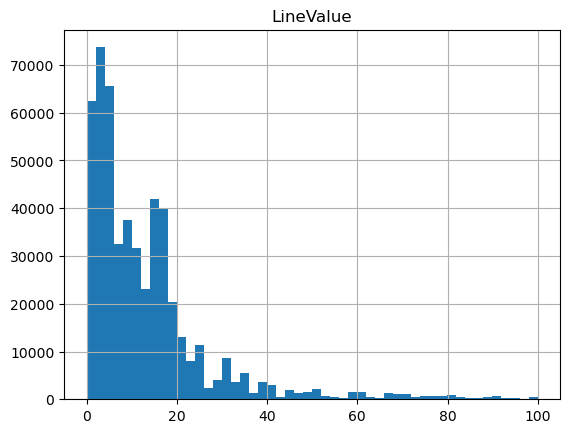

In [13]:
cust_clean[cust_clean['LineValue'] < 100].hist(column='LineValue', bins=50)

In [14]:
customer_df = cust_clean.groupby('CustomerID').agg({
    'LineValue': 'sum',
    'InvoiceNo': 'nunique'
}).rename(columns={
    'LineValue': 'TotalSpend',
    'InvoiceNo': 'OrderCount'
}).reset_index()

In [15]:
customer_df.corr(numeric_only=True)

,CustomerID,TotalSpend,OrderCount
CustomerID,1.000000,-0.013691,-0.010971
TotalSpend,-0.013691,1.000000,0.553650
OrderCount,-0.010971,0.553650,1.000000


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = customer_df[['OrderCount']]
y = customer_df['TotalSpend']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.24292349940977398

In [17]:
threshold = customer_df['TotalSpend'].quantile(0.8)
customer_df['HighValue'] = (customer_df['TotalSpend'] >= threshold).astype(int)

In [18]:
HighValue = TotalSpend >= 80th percentile

SyntaxError: invalid decimal literal (3853359134.py, line 1)

<Axes: >

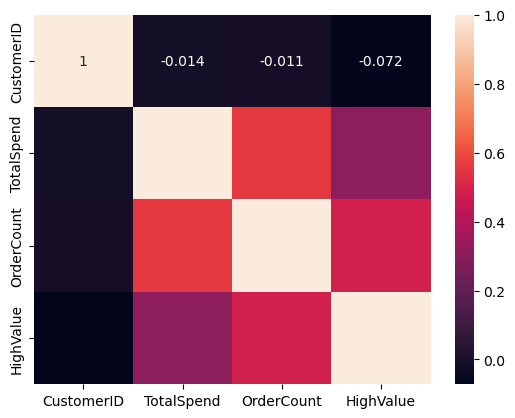

In [19]:
import seaborn as sns
sns.heatmap(customer_df.corr(numeric_only=True), annot=True)

In [20]:
top_products = cust_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48474
WHITE HANGING HEART T-LIGHT HOLDER    37891
POPCORN HOLDER                        36761
ASSORTED COLOUR BIRD ORNAMENT         36461
PACK OF 72 RETROSPOT CAKE CASES       36419
RABBIT NIGHT LIGHT                    30788
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [21]:
top_revenue_products = cust_clean.groupby('Description')['LineValue'].sum().sort_values(ascending=False).head(10)
top_revenue_products

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: LineValue, dtype: float64

<Axes: xlabel='Description'>

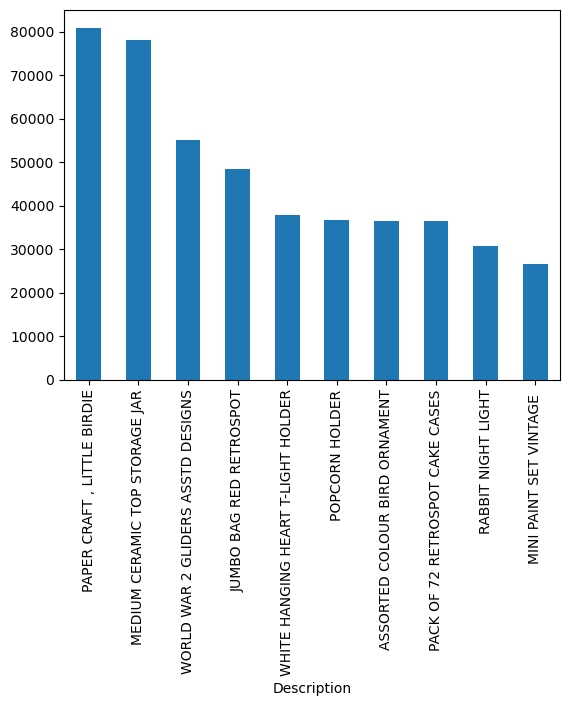

In [22]:
top_products.plot(kind='bar')

In [23]:
product_df = cust_clean.groupby('Description').agg({
    'Quantity': 'sum',
    'LineValue': 'sum'
}).reset_index()

In [24]:
product_df['AvgPrice'] = product_df['LineValue'] / product_df['Quantity']

In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = product_df[['Quantity', 'LineValue', 'AvgPrice']]

scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
product_df['Cluster'] = kmeans.fit_predict(scaled)

**1. Initial exploration**

- You can use the DataFrame methods from pandas, such as DataFrame.head(), DataFrame.info(), DataFrame.describe(), etc, to investigate the data.
- Alternatively use the following package:

In [ ]:
# from pandas_profiling import ProfileReport
# prof = ProfileReport(your_dataframe)
# prof.to_file(output_file='dataset_name.html')

In [4]:
cust.shape

(541909, 8)

In [5]:
cust.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
cust.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
cust.isna().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

In [8]:
(cust.isna().mean()*100).sort_values(ascending=False)

CustomerID     24.926694
Description     0.268311
StockCode       0.000000
InvoiceNo       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64

In [9]:
cust.duplicated().sum()

np.int64(5268)

In [11]:
cust[cust['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [12]:
cust[cust['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [13]:
(cust['Quantity'] < 0).sum()

np.int64(10624)

In [14]:
cust[cust['UnitPrice'] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [15]:
(cust['UnitPrice'] <= 0).sum()

np.int64(2517)

In [16]:
cust['InvoiceNo'].value_counts().head()

InvoiceNo
573585    1114
581219     749
581492     731
580729     721
558475     705
Name: count, dtype: int64

In [17]:
cust['Country'].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [18]:
cust['Description'].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64

In [19]:
cust.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [20]:
def profile_dataset(df):
    print("\n--- DATASET SHAPE ---")
    print(df.shape)

    print("\n--- COLUMN TYPES ---")
    print(df.dtypes)

    print("\n--- MISSING VALUES ---")
    print(df.isna().sum().sort_values(ascending=False))

    print("\n--- DUPLICATE ROWS ---")
    print(df.duplicated().sum())

    print("\n--- NUMERIC SUMMARY ---")
    print(df.describe())

    print("\n--- UNIQUE VALUE COUNTS ---")
    print(df.nunique().sort_values())

In [21]:
profile_dataset(cust)


--- DATASET SHAPE ---
(541909, 8)

--- COLUMN TYPES ---
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

--- MISSING VALUES ---
CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

--- DUPLICATE ROWS ---
5268

--- NUMERIC SUMMARY ---
            Quantity                 InvoiceDate      UnitPrice     CustomerID
count  541909.000000                      541909  541909.000000  406829.000000
mean        9.552250  2011-07-04 13:34:57.156386       4.611114   15287.690570
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12346.000000
25%         1.000000         2011-03-28 11:34:00       1.250000   13953.000000
50%         3.000000       

In [22]:
def retail_checks(df):

    print("\n--- NEGATIVE QUANTITIES (Returns) ---")
    print((df["Quantity"] < 0).sum())

    print("\n--- ZERO OR NEGATIVE PRICES ---")
    print((df["UnitPrice"] <= 0).sum())

    print("\n--- UNIQUE CUSTOMERS ---")
    print(df["CustomerID"].nunique())

    print("\n--- UNIQUE PRODUCTS ---")
    print(df["StockCode"].nunique())

In [23]:
retail_checks(cust)


--- NEGATIVE QUANTITIES (Returns) ---
10624

--- ZERO OR NEGATIVE PRICES ---
2517

--- UNIQUE CUSTOMERS ---
4372

--- UNIQUE PRODUCTS ---
4070


In [24]:
profile_dataset(cust)
retail_checks(cust)


--- DATASET SHAPE ---
(541909, 8)

--- COLUMN TYPES ---
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

--- MISSING VALUES ---
CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

--- DUPLICATE ROWS ---
5268

--- NUMERIC SUMMARY ---
            Quantity                 InvoiceDate      UnitPrice     CustomerID
count  541909.000000                      541909  541909.000000  406829.000000
mean        9.552250  2011-07-04 13:34:57.156386       4.611114   15287.690570
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12346.000000
25%         1.000000         2011-03-28 11:34:00       1.250000   13953.000000
50%         3.000000       

- What are your initial observations about the data?

Initial profiling of the dataset indicates that it contains 541,909 transactional records across 8 columns, representing individual product purchases within retail invoices. Each row appears to represent a single product line item within an invoice, meaning that a single transaction may contain multiple rows when multiple products were purchased together.

The dataset contains a mixture of categorical, numeric, and temporal variables. Product identifiers (StockCode), invoice identifiers (InvoiceNo), product descriptions (Description), and geographic information (Country) represent categorical fields. Numerical variables include Quantity and UnitPrice, while InvoiceDate provides a timestamp for each transaction.

Several data quality issues were identified during the initial exploration. The CustomerID column contains a significant number of missing values (135,080 records), indicating that a portion of transactions were recorded without an associated customer account. The Description column also contains a smaller number of missing values.

The dataset also contains duplicate records, with 5,268 duplicate rows detected. These duplicates may require removal during the data cleaning stage to avoid inflating transaction counts or biasing analysis.

Inspection of numeric fields revealed unusual values in the Quantity and UnitPrice columns. Negative quantities appear in the dataset and likely represent product returns or cancelled orders. Similarly, some unit prices are zero or negative, which may indicate pricing adjustments, refunds, or data entry anomalies.

The dataset includes 4,372 unique customers, 4,070 unique products, and transactions across 38 countries, suggesting a diverse retail operation with a broad customer base and product catalogue.

Overall, the dataset appears suitable for analysing retail purchasing behaviour and building models such as customer segmentation, product recommendation systems, or sales trend analysis, although several data quality issues must be addressed during the data preparation stage.

**2. Connect to the Business Context**

- Based on the business problem of analysing customer purchasing behaviour, which columns are most relevant to your task?
- Which columns help identify top products or understand a customer's purchase?

The dataset represents retail transaction records, where each row corresponds to a product purchased within an invoice. The business objective is to analyse customer purchasing behaviour and product demand, which may support activities such as product recommendation, demand analysis, or customer segmentation.

To achieve this objective, several columns are particularly relevant because they describe what was purchased, by whom, when, and at what price.

Columns Relevant for Analysing Customer Purchases

The following columns are most important for understanding a customer’s purchasing behaviour:

CustomerID
Identifies the individual customer making the purchase. This field enables customer-level analysis such as purchase frequency, average spend, and segmentation.

InvoiceNo
Represents the transaction identifier. It groups together multiple products purchased in a single order.

InvoiceDate
Indicates when the transaction occurred. This column allows analysis of purchasing patterns over time, including seasonal trends or purchase frequency.

Quantity
Represents the number of units purchased for each product line within the transaction.

UnitPrice
Provides the price per item, allowing calculation of transaction value and customer spending.

Columns Useful for Identifying Top Products

The following columns help determine which products are most popular or frequently purchased:

StockCode
The product identifier. This allows grouping of transactions by product to calculate total sales volume.

Description
Provides the product name or description, making it easier to interpret product-level analysis results.

Quantity
When aggregated by product, this column indicates the total number of items sold, which helps identify top-performing products.

Supporting Contextual Information

Country
Provides geographic information about where the customer is located. This allows analysis of purchasing behaviour across different markets.

Summary

The most critical columns for analysing customer purchasing behaviour are CustomerID, InvoiceNo, InvoiceDate, Quantity, and UnitPrice, as they capture who made the purchase, what was bought, and when it occurred.

For identifying top products, StockCode, Description, and Quantity are particularly useful, as they allow products to be grouped and ranked based on sales volume.

These fields form the core variables required for further analysis and potential machine learning tasks related to customer behaviour or product recommendations.

**3. Identify the data quality issues**

Identify Data Quality Issues in your selected columns. Now that you've chosen the columns you believe are most relevant, perform a detailed analysis to identify specific issues like missing values, inconsistent formats, incorrect data types, unusual values etc, within those columns only.
The main data quality issues in the selected columns are:

large number of missing values in CustomerID

some missing values in Description

duplicate rows

negative and extreme values in Quantity

zero or negative values in UnitPrice

CustomerID stored as float rather than a cleaner identifier type

These issues are important because they directly affect the reliability of customer-level analysis, product demand analysis, and any future machine learning models built from the dataset.

**4. Initial data cleaning and transformation**

(Each person from the group)Choose a relevant column with one or multiple data issues and try to address them. For example: missing values, incorrect data type, mixed types of values, etc.

In [25]:
cust = cust.dropna(subset=['CustomerID'])

In [26]:
cust['CustomerID'] = cust['CustomerID'].astype(int)

In [28]:
returns = cust[cust['Quantity'] < 0]

matched_pairs = cust.merge(
    returns,
    on=['StockCode', 'CustomerID', 'UnitPrice'],
    suffixes=('_sale','_return')
)

matched_pairs = matched_pairs[
    matched_pairs['Quantity_sale'] == -matched_pairs['Quantity_return']
]

In [29]:
matched_pairs.shape

(5600, 13)

In [30]:
matched_pairs.head()

,InvoiceNo_sale,StockCode,Description_sale,Quantity_sale,InvoiceDate_sale,UnitPrice,CustomerID,Country_sale,InvoiceNo_return,Description_return,Quantity_return,InvoiceDate_return,Country_return
1,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,C543611,HAND WARMER RED RETROSPOT,-6,2011-02-10 14:38:00,United Kingdom
4,536372,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 09:01:00,1.85,17850,United Kingdom,C543611,HAND WARMER RED RETROSPOT,-6,2011-02-10 14:38:00,United Kingdom
6,536373,21071,VINTAGE BILLBOARD DRINK ME MUG,6,2010-12-01 09:02:00,1.06,17850,United Kingdom,C543611,VINTAGE BILLBOARD DRINK ME MUG,-6,2011-02-10 14:38:00,United Kingdom
9,536373,82483,WOOD 2 DRAWER CABINET WHITE FINISH,2,2010-12-01 09:02:00,4.95,17850,United Kingdom,C543611,WOOD 2 DRAWER CABINET WHITE FINISH,-2,2011-02-10 14:38:00,United Kingdom
19,536375,21071,VINTAGE BILLBOARD DRINK ME MUG,6,2010-12-01 09:32:00,1.06,17850,United Kingdom,C543611,VINTAGE BILLBOARD DRINK ME MUG,-6,2011-02-10 14:38:00,United Kingdom


In [31]:
matched_pairs['InvoiceNo_sale'].nunique()

2336

In [32]:
matched_pairs['Quantity_return'].sum()

np.int64(-274598)

In [33]:
returns['InvoiceNo'].nunique()

3654

In [34]:
matched_pairs['InvoiceNo_return'].nunique()

1401

Analysis of the Quantity column revealed 3654 invoices containing negative quantities, indicating product returns or transaction corrections. By matching negative entries with positive transactions using product code, customer identifier, unit price, and opposite quantity values, 1401 return invoices were successfully paired with original purchases. These pairs likely represent reversal entries and should be removed from the analytical dataset to prevent double counting of transactions.

**5. Bonus task: Early feature engineering:**

Discuss and implement the potential feature engineering opportunities in this dataset. What new columns can you create from the existing ones that might enhance the next steps of the AI project?

Customer Purchase Frequency

Customer behaviour can be captured by calculating how frequently each customer places orders.

In [47]:
customer_purchase_count \
    .drop_duplicates() \
    .sort_values(by='CustomerPurchaseCount', ascending=False) \
    .head(10)


customer_purchase_count.head(10)

,CustomerID,CustomerPurchaseCount
4042,17841,7983
1895,14911,5903
1300,14096,5128
330,12748,4642
1674,14606,2782
2192,15311,2491
1703,14646,2085
568,13089,1857
698,13263,1677
1447,14298,1640


In [49]:
cust['CustomerPurchaseCount'] = cust.groupby('CustomerID')['CustomerID'].transform('count')

In [50]:
cust[['CustomerID','CustomerPurchaseCount']] \
.drop_duplicates() \
.sort_values(by='CustomerPurchaseCount', ascending=False) \
.head(10)

,CustomerID,CustomerPurchaseCount
1441,17841,7983
1404,14911,5903
317502,14096,5128
1016,12748,4642
2421,14606,2782
106,15311,2491
37952,14646,2085
7440,13089,1857
62628,13263,1677
29815,14298,1640


In [51]:
customer_purchase_count.head(10)

,CustomerID,CustomerPurchaseCount
4042,17841,7983
1895,14911,5903
1300,14096,5128
330,12748,4642
1674,14606,2782
2192,15311,2491
1703,14646,2085
568,13089,1857
698,13263,1677
1447,14298,1640


Product Popularity

A product-level feature can be derived to indicate how often a product appears in the dataset.

In [39]:
cust['ProductPurchaseCount'] = cust.groupby('StockCode')['InvoiceNo'].transform('count')

In [40]:
cust[['StockCode','Description','ProductPurchaseCount']] \
.drop_duplicates() \
.sort_values(by='ProductPurchaseCount', ascending=False) \
.head(10)

,StockCode,Description,ProductPurchaseCount
537621,85123A,CREAM HANGING HEART T-LIGHT HOLDER,2077
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2077
880,22423,REGENCY CAKESTAND 3 TIER,1905
177,85099B,JUMBO BAG RED RETROSPOT,1662
9,84879,ASSORTED COLOUR BIRD ORNAMENT,1418
6572,47566,PARTY BUNTING,1416
93,20725,LUNCH BAG RED RETROSPOT,1359
58132,20725,LUNCH BAG RED SPOTTY,1359
28715,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1232
45,POST,POSTAGE,1196


In [41]:
cust['StockCode'].nunique()

3684

In [42]:
cust[['StockCode','ProductPurchaseCount']] \
.drop_duplicates()['ProductPurchaseCount'] \
.describe()

count    3684.000000
mean      110.431325
std       167.528090
min         1.000000
25%        12.000000
50%        49.000000
75%       139.000000
max      2077.000000
Name: ProductPurchaseCount, dtype: float64

In [52]:
from pathlib import Path

project_dir = Path.cwd().parent
interim_dir = project_dir / "data" / "interim"

interim_dir.mkdir(parents=True, exist_ok=True)

output_file = interim_dir / "online_retail_cleaned.csv"

cust.to_csv(output_file, index=False)

print("Dataset written to:", output_file)

Dataset written to: f:\VScode\ai-apprenticeship-session6\ai-apprenticeship-02-data-lifecycle\group2\data\interim\online_retail_cleaned.csv
